In [1]:
import os
# os.chdir('../Interviews/GiveMeSomeCredit')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import random

import seaborn as sns #For plotting graphs
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower

import seaborn as sns #For plotting graphs
sns.set_style("whitegrid")

# Recursive Feature Elimination


from functions import *

import warnings
warnings.filterwarnings("ignore")

In [9]:
df_test_y = pd.read_csv('/home/ec2-user/SageMaker/sandbox/Interviews/GiveMeSomeCredit/df_test_y_Not_Shared_w_Candidates.csv')
df_test_y.head(2)

,ID,Target_90Plus_DPD_In_2yrs
0,39796,0
1,86080,0


In [10]:
df_test_pred_y = pd.read_csv('/home/ec2-user/SageMaker/sandbox/Interviews/GiveMeSomeCredit/pradeep_xgboost.csv')
df_test_pred_y.head(2)

,ID,y_pred
0,39796,0.0737
1,86080,0.0155


In [11]:
df_test = pd.merge(df_test_y,df_test_pred_y,how='inner',on='ID')
df_test.head(2)

,ID,Target_90Plus_DPD_In_2yrs,y_pred
0,39796,0,0.0737
1,86080,0,0.0155


In [5]:
def check_missing(data):
    MissTotal = data.isnull().sum().sort_values(ascending=False)
    percent = round((data.isnull().sum()/list(data.shape)[0]*100),2).sort_values(ascending=False)
    count = data.isnull().count().sort_values(ascending=False)
    missing_data = pd.concat([MissTotal, percent, count], axis=1, keys=['MissingTotal', 'MissingPercent', 'Total'])
    # print(missing_data[missing_data['MissingPercent']>0].head(10))
    print(missing_data.head(10))
    
def performance_metrics(y_true, y_pred, threshold=0.5):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    y_pred_bin = np.round(y_pred)
    #y_pred_bin = [0 if y < threshold else 1 for y in y_pred]
    d={}
    d['accuracy'] = accuracy_score(y_true, y_pred_bin)
    d['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred_bin)
    d['precision'] = precision_score(y_true, y_pred_bin)
    d['recall'] = recall_score(y_true, y_pred_bin)
    d['RMSE'] = mean_squared_error(y_true, y_pred, squared=False)
    cm = confusion_matrix(y_true, y_pred_bin)
    cm = pd.DataFrame(cm, index=[['Observed','Observed'],['False','True']],\
                      columns=[['Predicted','Predicted'],['False','True']])
    text = 'Performance Metrics\n'
    p = 20
    for i,j in d.items():
        text += '\n{}{} = {:.3f}'.format(i.title(),' '*(p-len(i)),j)
    print(text,'\n\nConfusion Matrix')
    return print(cm)

def plot_auc1(y_true,y_pred,title=''):
    y_true = np.ravel(y_true)
    # for i in array of y_pred
    y_pred = np.ravel(y_pred)
    fpr,tpr,thresholds = roc_curve(y_true,y_pred)
    ks = max(tpr-fpr)
    AUC = roc_auc_score(y_true,y_pred)
    plt.plot(fpr,tpr,color='tab:blue',label='AUC = {} KS = {}'.format(round(AUC,3),round(ks,3)))
    plt.title(title)
    
    plt.plot([0,1],[0,1],linestyle='--',color='black',label='Random')
    plt.xlabel('False Positive Rate (1-Specificity) = FP/(FP+TN)')
    plt.ylabel('True Positive Rate (Sensitivity) = TP/(TP+FN)')
    plt.legend(loc='lower right')
    plt.show()
    return
    
def exp_vs_act(df,score,target):
       
    #print(df.info())
    orig_feature = score
    
    #CREATE THE SUMMARY TABLE
    if str(df[orig_feature].dtype) !='object':
        grp_range = 'grp_' + score
        df[grp_range] = pd.qcut(df[score], q=10, labels=None, retbins = False, precision=4, duplicates = 'raise')
        df['grp_num'] = (pd.qcut(df[score], q=10, labels=False, retbins = False, precision=4, duplicates = 'raise')+1).astype(str).str.zfill(2)
        df['grp'] = df['grp_num'].astype(str) + ' ' +df[grp_range].astype(str)
        score = 'grp'
        
    non_events = pd.DataFrame(df[df[target]==0].groupby([score],dropna=False)[target].count()).rename(columns={target: 'non_events'})
    non_events_total = df[df[target]==0].groupby([target],dropna=False)[target].count()
    events = pd.DataFrame(df[df[target]==1].groupby([score],dropna=False)[target].count()).rename(columns={target: 'events'})
    events_total = df[df[target]==1].groupby([target],dropna=False)[target].count()
    grand_total = df[target].count()
    result = pd.merge(non_events, events, how="left",on=score)
    
    if str(df[orig_feature].dtype) !='object':
        pred_events = round(pd.DataFrame(df.groupby([score],dropna=False)[orig_feature].sum()),1).rename(columns={orig_feature: 'pred_events'})
        result = pd.merge(result, pred_events, how="left",on=score)
        
    result['total'] = result['non_events'] + result['events']
    result['act_event_rate'] = round(result['events']/result['total'],3)
    if str(df[orig_feature].dtype) !='object':
        result['pred_event_rate'] = round(result['pred_events']/result['total'],3)
    result['% event dist'] = result['events']/(events_total.values)
    result['% non-event dist'] = result['non_events']/(non_events_total.values)
    result['% total dist'] = round(result['total']/grand_total*100,1)
    cond = ((result['% non-event dist']==0) | (result['% event dist'] ==0)) # Dont calculate WOE and IV if the bin has missing values of events and/or non-events
    result.loc[~cond,"WoE"] = np.log(result.loc[~cond,"% non-event dist"]/result.loc[~cond,"% event dist"])
    result.loc[~cond,"IV"] = (result['% non-event dist']-result['% event dist'])*result['WoE']

    # Calculate IV
    IV = round(result.IV.sum(),6)
    #print('Information Value of',"'"+score+"'",'is', IV)
    
    #round off the decimal places for better display
    result['% event dist'] = round(result['% event dist']*100,1)
    result['% non-event dist'] = round(result['% non-event dist']*100,1)
    result['WoE'] = round(result['WoE'],2)
    result['IV'] = round(result['IV'],2) 
    
    # convert index (score) to column
    result.reset_index(inplace=True)
    
    # Replace nan with Missing
    result[score]=result[score].replace(np.nan, 'Missing', regex=True)
    
    ax = result.plot(x='grp', y=['act_event_rate','pred_event_rate'],marker="*")
    ax.set_xticks(range(len(result)))
    p = ax.set_xticklabels([item for item in result.grp.tolist()],rotation=45)
    return result

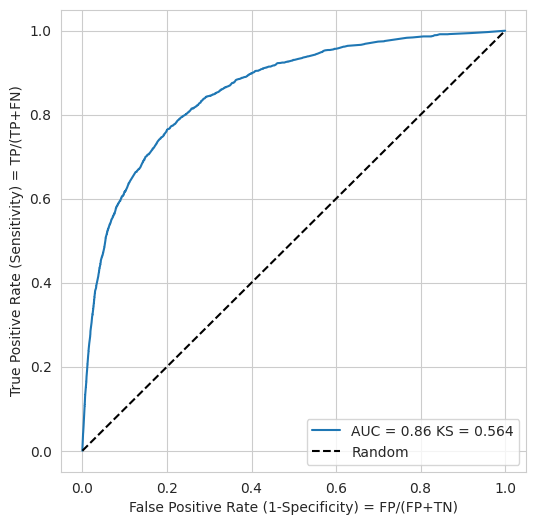

In [6]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(6,6)
plot_auc1(df_test['Target_90Plus_DPD_In_2yrs'], df_test['y_pred'])

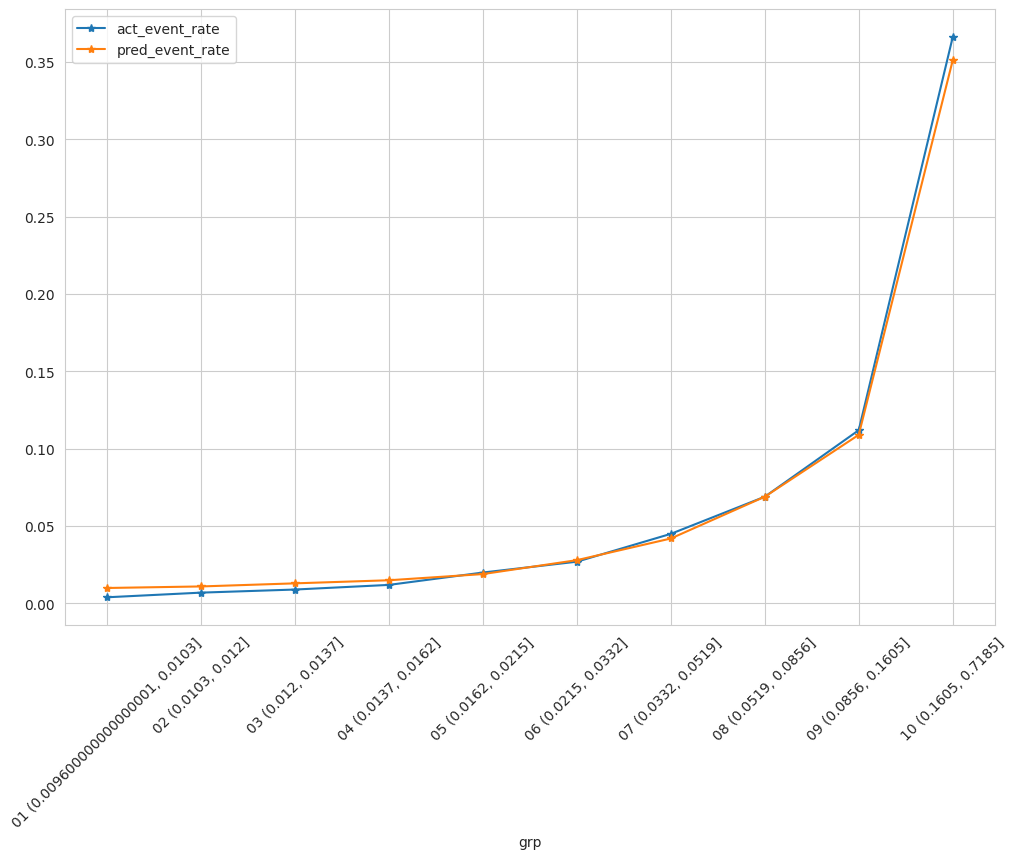

In [7]:
ror_test = exp_vs_act(df_test,'y_pred','Target_90Plus_DPD_In_2yrs')

In [8]:
performance_metrics(df_test['Target_90Plus_DPD_In_2yrs'], df_test['y_pred'])

Performance Metrics

Accuracy             = 0.936
Balanced_Accuracy    = 0.577
Precision            = 0.564
Recall               = 0.162
Rmse                 = 0.223 

Confusion Matrix
               Predicted     
                   False True
Observed False     34680  314
         True       2100  406
